<a href="https://colab.research.google.com/github/kimanirobbi/wk-6-ai/blob/main/Part_2_Practical_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Edge AI Prototype

## Code Implementation

### Setup and Imports

In [ ]:
import os
import numpy as np
import tensorflow as tf

# Attempt to import tflite_model_maker to see if it's available
try:
    from tflite_model_maker import model_spec
    from tflite_model_maker import image_classifier
    from tflite_model_maker.config import ExportFormat
    from tflite_model_maker.image_classifier import DataLoader
    print("tflite_model_maker imported successfully.")
except ImportError:
    print("tflite_model_maker not found, attempting installation...")
    # Upgrade pip to the latest version and then install the required libraries
    !pip install --upgrade pip
    !pip install numpy==1.22.4 # Install a compatible numpy version explicitly
    !pip install tflite-model-maker
    # Re-attempt import after installation
    try:
        from tflite_model_maker import model_spec
        from tflite_model_maker import image_classifier
        from tflite_model_maker.config import ExportFormat
        from tflite_model_maker.image_classifier import DataLoader
        print("tflite_model_maker imported successfully after re-installation.")
    except ImportError:
        print("Failed to import tflite_model_maker even after re-installation. Please check the output above for errors.")

import matplotlib.pyplot as plt


tflite_model_maker not found, attempting installation...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 78.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 107.4 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### Data Preparation (Using Sample Data)

In [13]:
# --- SIMULATE DATA DOWNLOAD (REPLACE WITH YOUR OWN DATA UPLOAD) ---
# This downloads a sample dataset (flower photos) structured correctly:
# root_dir/class_name_1/image1.jpg
# root_dir/class_name_2/image2.jpg
image_path = tf.keras.utils.get_file(
    'flower_photos.tgz',
    'https://storage.googleapis.com/download./www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification',
    extract=True)
image_path = os.path.join(os.path.dirname(image_path), 'flower_photos')
# -------------------------------------------------------------------

# Load the data and split it into training and testing sets (90% train, 10% test)
# The DataLoader automatically infers class labels from the folder names.
print(f"Loading data from: {image_path}")
data = DataLoader.from_folder(image_path)
train_data, test_data = data.split(0.9)

print(f"Total training examples: {len(train_data)}")
print(f"Total testing examples: {len(test_data)}")
print(f"Class labels: {data.index_to_label}")

Loading data from: /root/.keras/datasets/flower_photos


NameError: name 'DataLoader' is not defined

### Model Training and Evaluation

In [ ]:
# Choose a lightweight model specification (EfficientNet-Lite0 is TFLite optimized)
model_spec_lite = model_spec.get('efficientnet_lite0')

# Create and train the model using transfer learning
# The create function handles model customization, training, and compilation.
print("Starting model training (5 epochs)...")
model = image_classifier.create(
    train_data,
    model_spec=model_spec_lite,
    epochs=5,
    batch_size=32
)

# --- Evaluate the model ---
print("\n--- Evaluating Model Accuracy ---")
loss, accuracy = model.evaluate(test_data)

# DELIVERABLE: Accuracy Metrics
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

### TFLite Conversion and Export

In [14]:
# --- Kaggle Data Preparation Steps ----
# This cell will be used to set the path after downloading the Kaggle dataset.
# The actual download will happen in the subsequent cells.
image_path = '/kaggle/input/recyclable-and-household-waste-classification/DATASET/TRAIN'
# The DataLoader and data splitting will be performed in a separate cell
# after the dataset is successfully downloaded and extracted.

### **Kaggle Data Download Setup**

To download the dataset from Kaggle, please follow these steps:

1.  **Generate Kaggle API Token**: Go to your Kaggle account settings (`https://www.kaggle.com/<your-username>/account`), find the "API" section, and click "Create New Token". This will download a `kaggle.json` file to your computer.
2.  **Upload `kaggle.json` to Colab**:
    *   Click the "Files" icon (folder icon) on the left-hand sidebar of Colab.
    *   Click the "Upload to session storage" icon (up-arrow) and upload your `kaggle.json` file.
3. **Run using python 3.8 or 3.9**
4.  **Run the following cell to set up Kaggle environment and download the dataset.**

In [1]:
# Install Kaggle API client
!pip install -q kaggle

# Create a .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Copy kaggle.json to the .kaggle directory
# This assumes you have uploaded kaggle.json to your Colab session storage
!cp kaggle.json ~/.kaggle/

# Set permissions for kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Define the dataset path on Kaggle
KAGGLE_DATASET_PATH = 'alistairking/recyclable-and-household-waste-classification'

# Download the dataset
print(f"Downloading Kaggle dataset: {KAGGLE_DATASET_PATH}...")
!kaggle datasets download -d {KAGGLE_DATASET_PATH}

# Unzip the dataset
print("Unzipping dataset...")
!unzip -q recyclable-and-household-waste-classification.zip -d /kaggle/input/
print("Dataset unzipped to /kaggle/input/")

# Verify the contents of the downloaded dataset (optional)
!ls -l /kaggle/input/recyclable-and-household-waste-classification/DATASET/
!ls -l /kaggle/input/recyclable-and-household-waste-classification/DATASET/TRAIN


LoadError: UndefVarError: `pip` not defined

In [1]:
# Load the data and split it into training and testing sets (90% train, 10% test)
# The DataLoader automatically infers class labels from the folder names.

# NOTE: This cell requires the tflite_model_maker library to be successfully imported.
# As noted previously, this library might be incompatible with the current Python 3.12 runtime.
# If you encounter a NameError for 'DataLoader', please refer to the previous explanation.

print(f"Loading data from: {image_path}")
data = DataLoader.from_folder(image_path)
train_data, test_data = data.split(0.9)

print(f"Total training examples: {len(train_data)}")
print(f"Total testing examples: {len(test_data)}")
print(f"Class labels: {data.index_to_label}")


NameError: name 'image_path' is not defined

In [ ]:
# Define the export directory and model filename
EXPORT_DIR = 'recycling_ai_output'
TFLITE_MODEL_FILENAME = 'recyclables_model.tflite'

# Create the export directory if it doesn't exist
os.makedirs(EXPORT_DIR, exist_ok=True)

# Export the model to TFLite format with full integer quantization for maximum edge optimization
# Full integer quantization reduces model size and improves inference speed on devices like the Raspberry Pi.
print(f"\n--- Exporting TFLite Model to {EXPORT_DIR}/{TFLITE_MODEL_FILENAME} ---")
model.export(
    export_dir=EXPORT_DIR,
    tflite_filename=TFLITE_MODEL_FILENAME,
    label_filename='labels.txt',
    export_format=[ExportFormat.TFLITE]
)

print("\nExport complete.")
print(f"Your model file ({TFLITE_MODEL_FILENAME}) and labels file (labels.txt) are in the '{EXPORT_DIR}' folder.")

# --- Deployment Step Explanation (DELIVERABLE: Deployment Steps) ---
# To deploy to Raspberry Pi:
# 1. Download the contents of the 'recycling_ai_output' folder (recyclables_model.tflite and labels.txt).
# 2. On the Raspberry Pi, install the tflite_runtime library:
#    !pip3 install tflite-runtime
# 3. Use the tflite_runtime Interpreter API to load the model and run inference on camera frames.

### Benefits of Edge AI for Real-Time Applications

**Edge AI Benefits for Real-Time Applications**

Edge AI (running machine learning inference directly on a local device like a Raspberry Pi) offers significant advantages for real-time applications, such as a smart recycling bin:

- **Reduced Latency** **(Real-Time Performance):** This is the most crucial benefit. By processing the image locally, there is no need to transmit the data to a remote cloud server and wait for the result to come back. This enables instantaneous decisions (ee.g., sorting the item) in milliseconds, which is vital for any application requiring immediate action.

- **Improved Reliability:** The system is independent of internet connectivity. The recycling sorter will continue to function even if the Wi-Fi or cellular network is down, ensuring continuous operation.

- **Enhanced Privacy and Security:** Sensitive or proprietary data (like images of items being processed) stays on the device and is not streamed to the cloud, reducing the risk of a data breach.

- **Lower Operating Costs:** By minimizing data transmission and reliance on constant cloud computing resources, Edge AI drastically reduces network bandwidth and cloud subscription costs.

# Task 2: AI-Driven IoT Concept

 ## sensors

In [ ]:
# Core Environmental Sensors
sensors = {
    "soil_moisture": "Measures water content in soil at multiple depths",
    "temperature": "Air and soil temperature monitoring",
    "humidity": "Air humidity levels",
    "light_intensity": "Sunlight exposure measurement",
    "rain_gauge": "Precipitation measurement",
    "wind_speed": "Wind velocity",
    "wind_direction": "Wind direction",
    "atmospheric_pressure": "Barometric pressure",

    # Soil Quality Sensors
    "soil_ph": "Soil acidity/alkalinity levels",
    "npk_sensor": "Nitrogen, Phosphorus, Potassium levels",
    "soil_conductivity": "Soil salinity and nutrient content",

    # Crop Health Sensors
    "multispectral_camera": "NDVI for plant health assessment",
    "thermal_camera": "Plant stress detection",
    "ultrasonic_sensor": "Plant height and growth monitoring"
}

print("Smart Agriculture IoT Sensor Suite:")
for sensor, description in sensors.items():
    print(f"✓ {sensor.replace('_', ' ').title()}: {description}")

## Proposed an AI model

In [ ]:
# Proposed AI/ML Pipeline for Yield Prediction
def create_yield_prediction_model():
    """
    Advanced AI model for crop yield prediction
    Combines multiple data sources and techniques
    """

    model_architecture = {
        "data_sources": {
            "real_time_sensor_data": [
                "soil_moisture_7day_avg",
                "temperature_7day_avg",
                "humidity_7day_avg",
                "light_intensity_cumulative",
                "npk_levels_current"
            ],
            "historical_data": [
                "past_yield_data_5years",
                "weather_patterns_historical",
                "soil_quality_history"
            ],
            "external_data": [
                "satellite_imagery_ndvi",
                "weather_forecasts_14day",
                "market_pricing_data"
            ]
        },

        "model_type": "Ensemble Regression Model",
        "components": [
            "Random Forest Regressor (main predictor)",
            "LSTM Neural Network (time series analysis)",
            "XGBoost (feature importance)",
            "Computer Vision CNN (satellite image analysis)"
        ],

        "input_features": [
            # Environmental Features
            "soil_moisture_avg", "temperature_avg", "humidity_avg",
            "rainfall_total", "sunlight_hours", "wind_speed_avg",

            # Soil Quality Features
            "ph_level", "nitrogen_level", "phosphorus_level",
            "potassium_level", "organic_matter",

            # Temporal Features
            "growing_days", "seasonal_factors", "crop_rotation_history",

            # Spatial Features
            "field_size", "elevation", "slope_angle",

            # Crop-Specific Features
            "crop_type", "planting_density", "irrigation_method"
        ],

        "output": "predicted_yield_kg_per_hectare",

        "performance_metrics": {
            "target_accuracy": "90%+ within 15% error margin",
            "r_squared": ">0.85",
            "mae": "<100 kg/hectare"
        }
    }

    return model_architecture

# Display the model architecture
model_design = create_yield_prediction_model()
print("=== AI MODEL FOR CROP YIELD PREDICTION ===")
print(f"Model Type: {model_design['model_type']}")
print(f"Key Components: {', '.join(model_design['components'])}")
print(f"Number of Input Features: {len(model_design['input_features'])}")
print(f"Target Accuracy: {model_design['performance_metrics']['target_accuracy']}")

### Data flow diagram

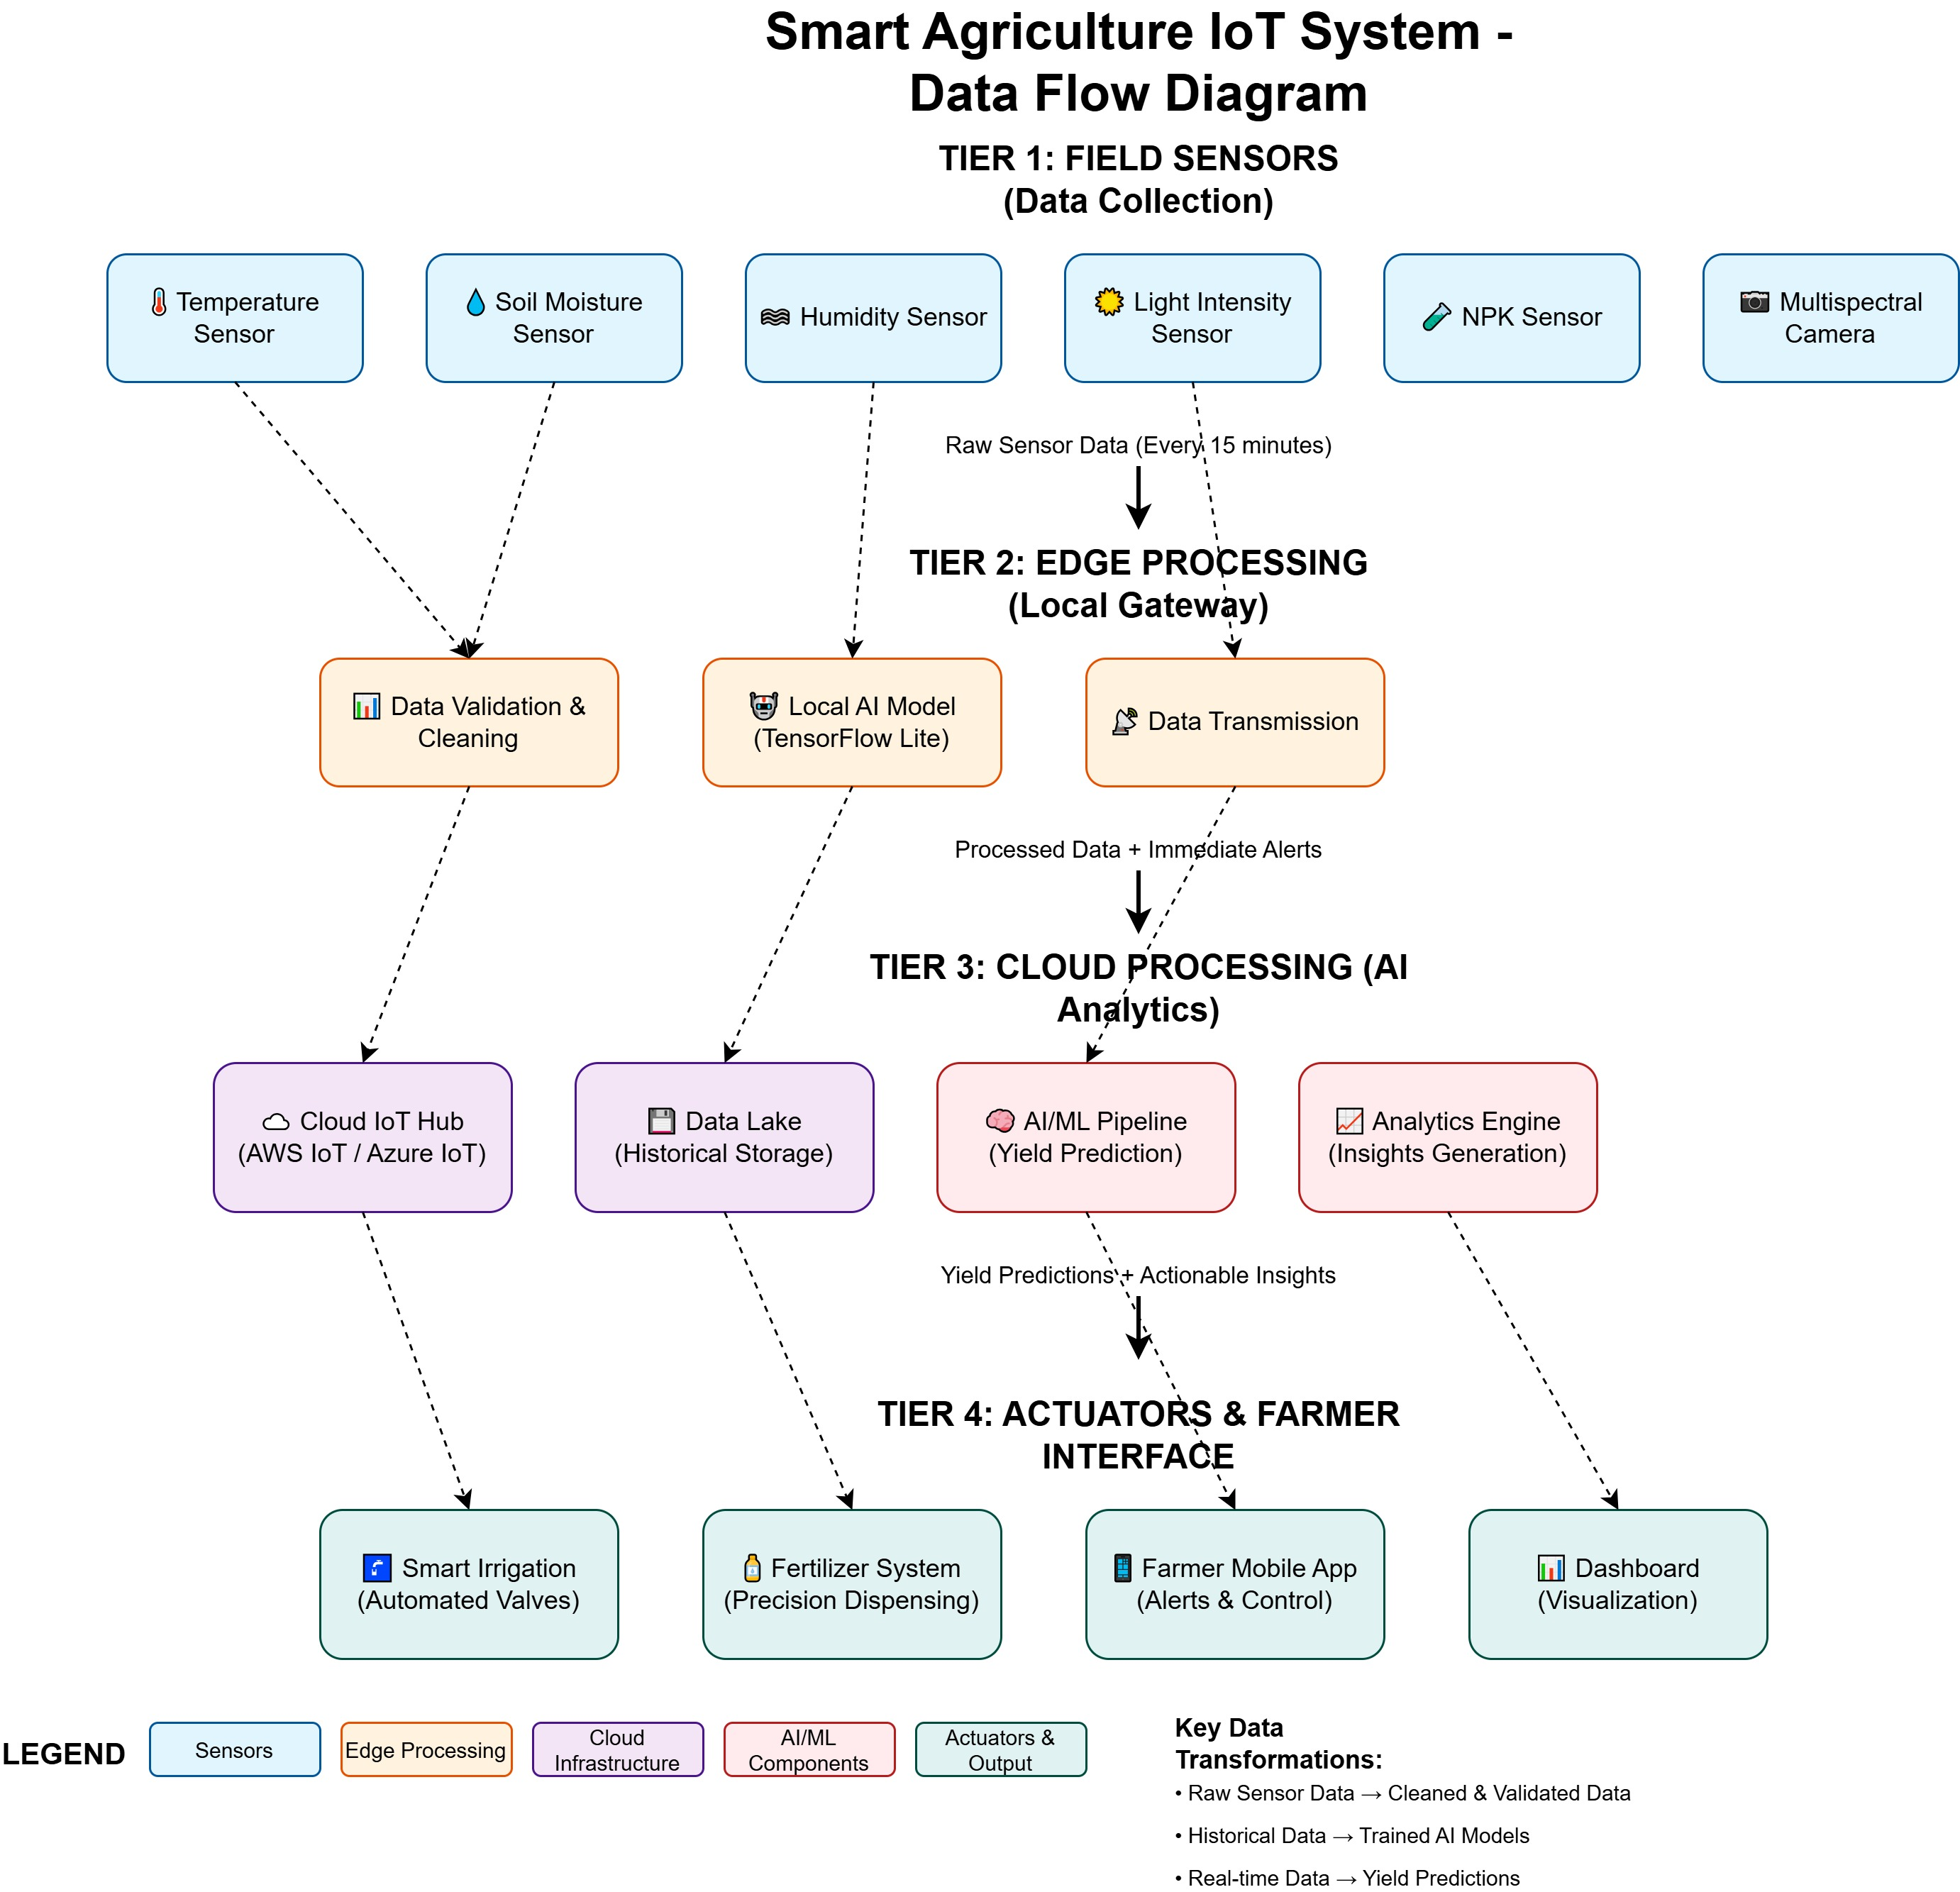